# Setup

In [97]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]  # adjust if notebook is nested
sys.path.append(str(PROJECT_ROOT))

print("Added to PYTHONPATH:", PROJECT_ROOT)

Added to PYTHONPATH: c:\Users\yfess\Desktop\timeseries-thesis


In [98]:
from dotenv import load_dotenv
import os

env_file = PROJECT_ROOT / ".env"

print( env_file.exists())

load_dotenv(env_file)

print("Loaded env file:", env_file)
print("DB PORT:", os.getenv("MONGODB_PORT"))

True
Loaded env file: c:\Users\yfess\Desktop\timeseries-thesis\.env
DB PORT: 27067


In [99]:
# from src.databases.benchmark_db.models import Benchmark 
from src.common.config import load_config
from src.common.logger import get_logger
from src.databases.benchmark_db.config import get_postgres_config
from src.databases.benchmark_db.benchmark_db import BenchmarkDB

In [100]:
bmdb_config_file_path = PROJECT_ROOT / "configs/config-benchmarkdb.yml"
bmdb_config_file_path

WindowsPath('c:/Users/yfess/Desktop/timeseries-thesis/configs/config-benchmarkdb.yml')

In [101]:
bmdb_config = load_config(bmdb_config_file_path)
bmdb_config

{'database': {'BENCHMARKDB_USER': 'yosafe',
  'BENCHMARKDB_PASSWORD': 'yosafe123',
  'BENCHMARKDB_DATABASE': 'db1',
  'BENCHMARKDB_HOST': '158.39.201.140',
  'BENCHMARKDB_PORT': '5432',
  'BENCHMARKDB_SCHEMA': 'public'},
 'general': {'log_file': './logs/benchmarkdb_logs.log'}}

In [102]:

logger = get_logger("benchmark_db", bmdb_config["general"]["log_file"])

benchmark_db_config = get_postgres_config(bmdb_config["database"])
bm_db = BenchmarkDB(benchmark_db_config, logger)
print(bm_db.connect())

None


In [103]:
import inspect
from src.databases.benchmark_db.models import IngestionBenchmarkResult
print("Benchmark result model file:", inspect.getfile(IngestionBenchmarkResult))
print("Benchmark result columns:", IngestionBenchmarkResult.__table__.columns.keys())

Benchmark result model file: c:\Users\yfess\Desktop\timeseries-thesis\src\databases\benchmark_db\models.py
Benchmark result columns: ['id', 'benchmark_name', 'database_system', 'database_version', 'database_location', 'insert_batch_size', 'batch_id', 'dataset_name', 'record_count', 'data_size_bytes', 'data_size_kb', 'data_size_mb', 'elapsed_time_seconds', 'elapsed_time_ns', 'throughput_obs_per_sec', 'throughput_bytes_per_sec', 'throughput_kb_per_sec', 'throughput_mb_per_sec', 'insert_operation_count', 'created_at']


In [104]:
benchmark_ALL  = bm_db.get_all_results()
len(benchmark_ALL)

2400

In [105]:
one_bm = benchmark_ALL[11]
print(one_bm)

IngestionBenchmarkResult 12
  benchmark:          ingestion.insert_many.fixed_batch
  database system:    mongodb
  database version:   8.0
  database location:  container
  insert batch size:  1000
  batch id:           12
  dataset:            batch_12_50000_obs.json
  record count:       50000
  data size bytes:    10691719
  data size kb:       10441.13
  data size mb:       10.196
  elapsed time:       0.700817 s
  elapsed time ns:    700817200 ns
  throughput obs/s:   71345.28
  throughput bytes/s: 15256073.91
  throughput kb/s:    14898.51
  throughput mb/s:    14.5487
  insert operations:  50
  created at:         2026-03-16T21:13:38.934997+00:00


# Analysis

In [106]:
import matplotlib.pyplot as plt
import pandas as pd

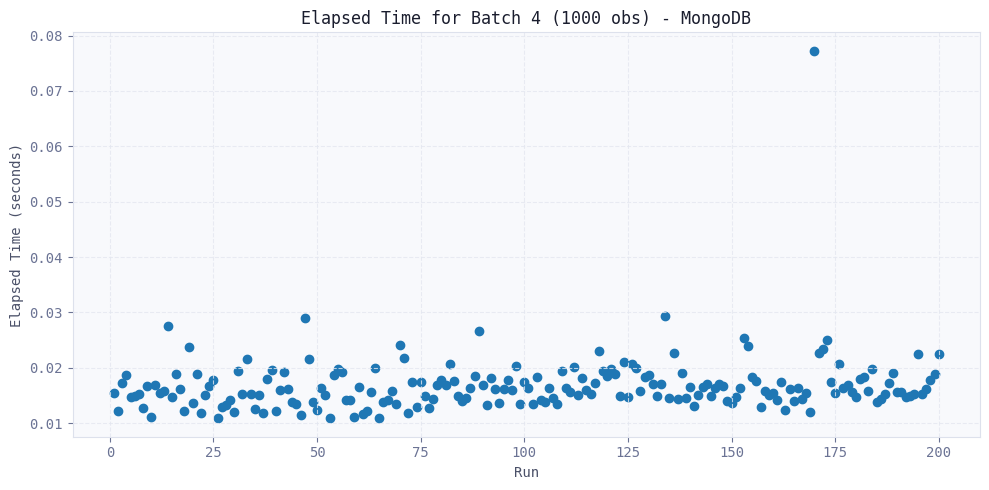

In [107]:
batch_id = 4
batch_12_results = [r for r in benchmark_ALL if r.batch_id == batch_id]
elapsed_times = [r.elapsed_time_seconds for r in batch_12_results]
run_numbers = list(range(1, len(batch_12_results) + 1))
plt.figure(figsize=(10, 5))
plt.scatter(run_numbers, elapsed_times, marker='o')
plt.title(f"Elapsed Time for Batch {batch_id} ({batch_12_results[0].record_count} obs) - MongoDB")
plt.xlabel("Run")
plt.ylabel("Elapsed Time (seconds)")
plt.grid(True)
plt.tight_layout()
plt.show()

## residual plot

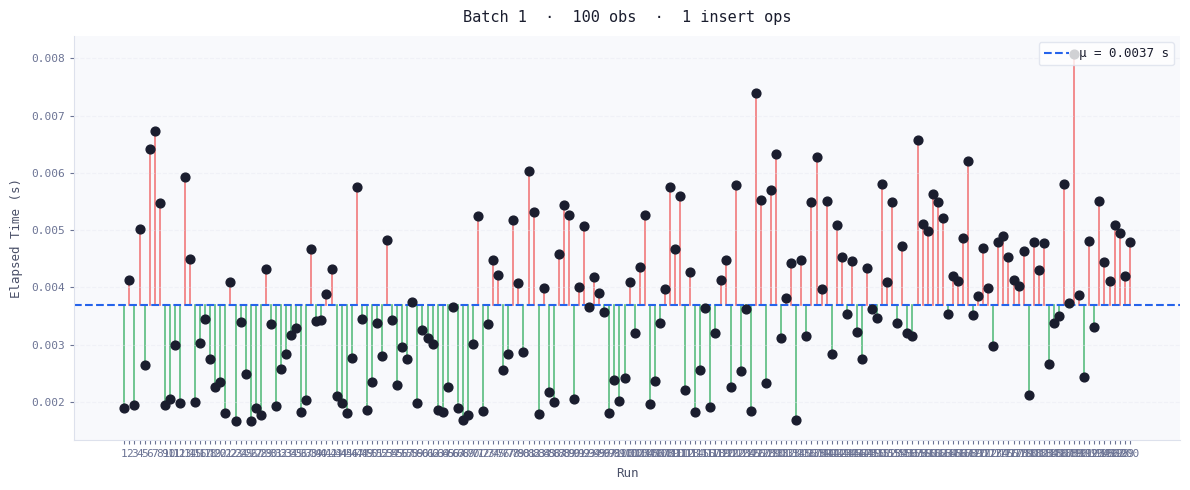

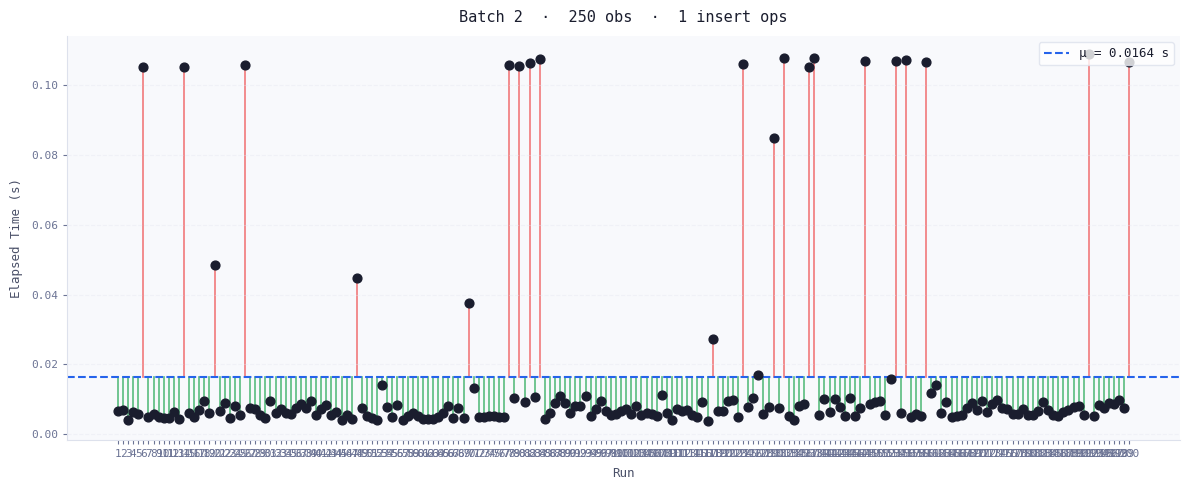

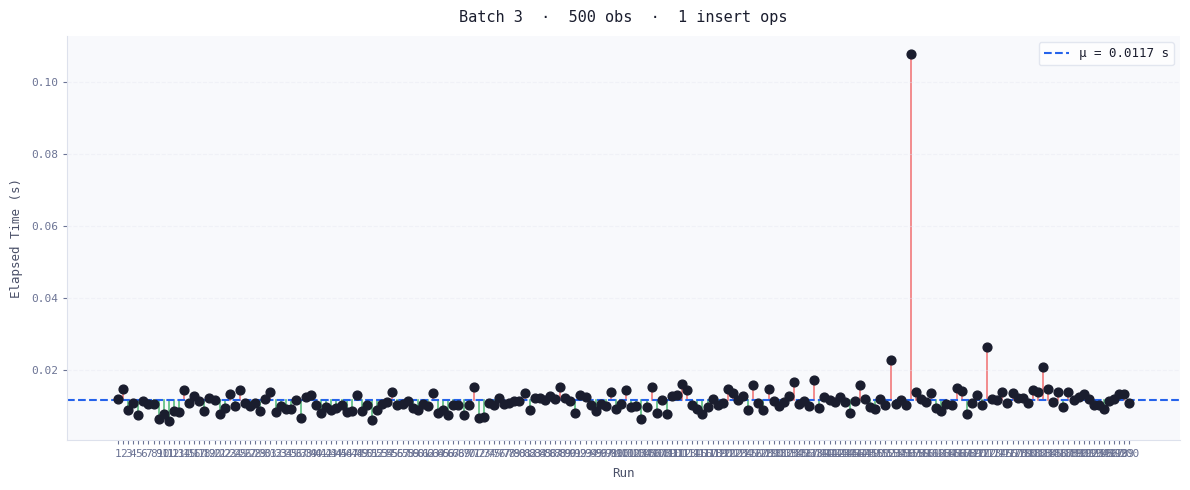

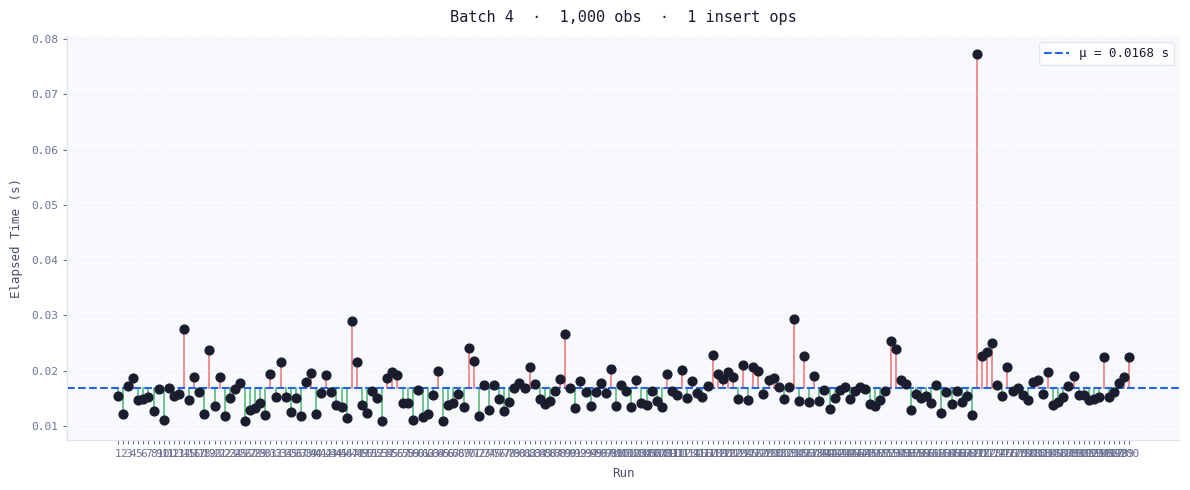

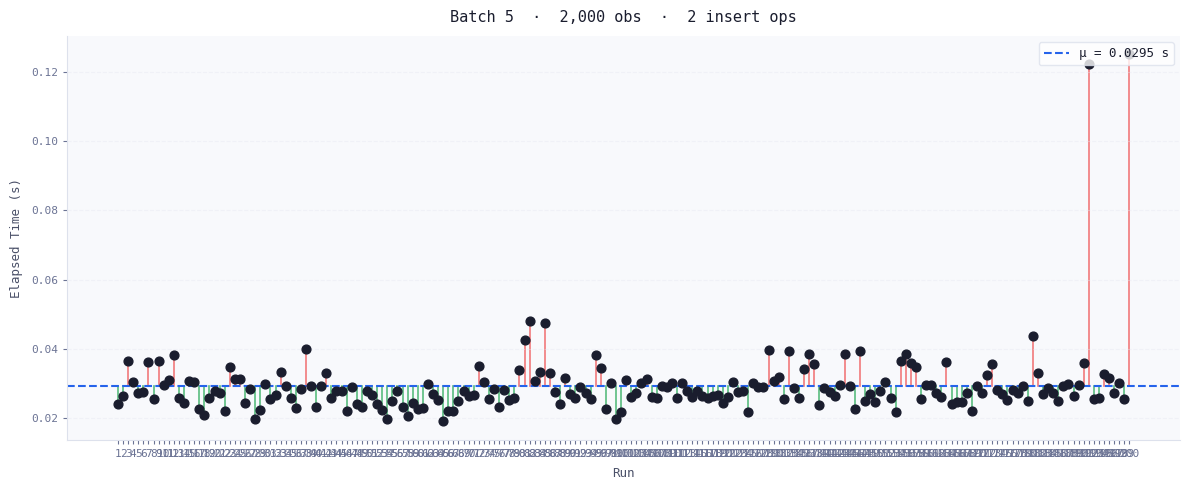

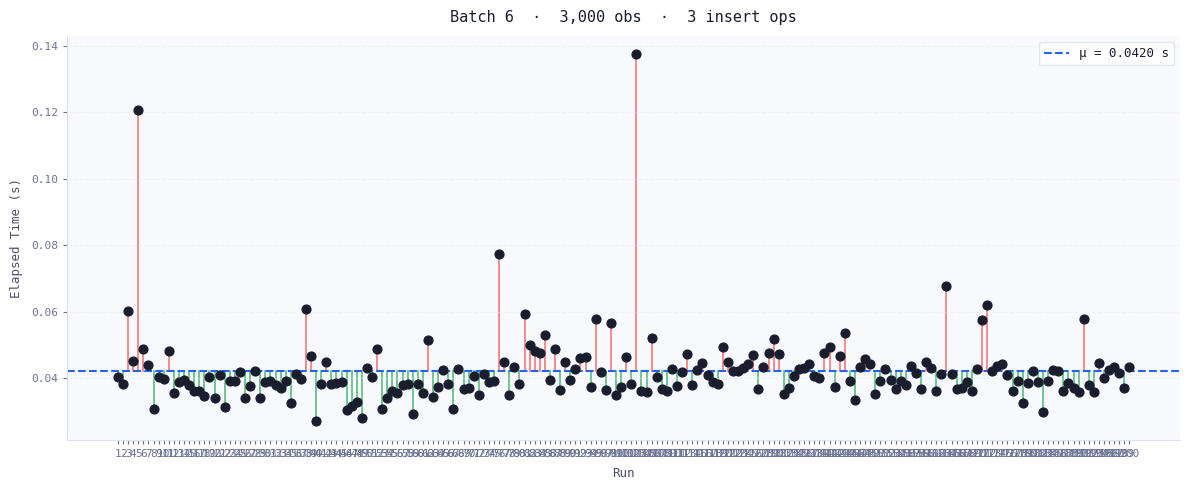

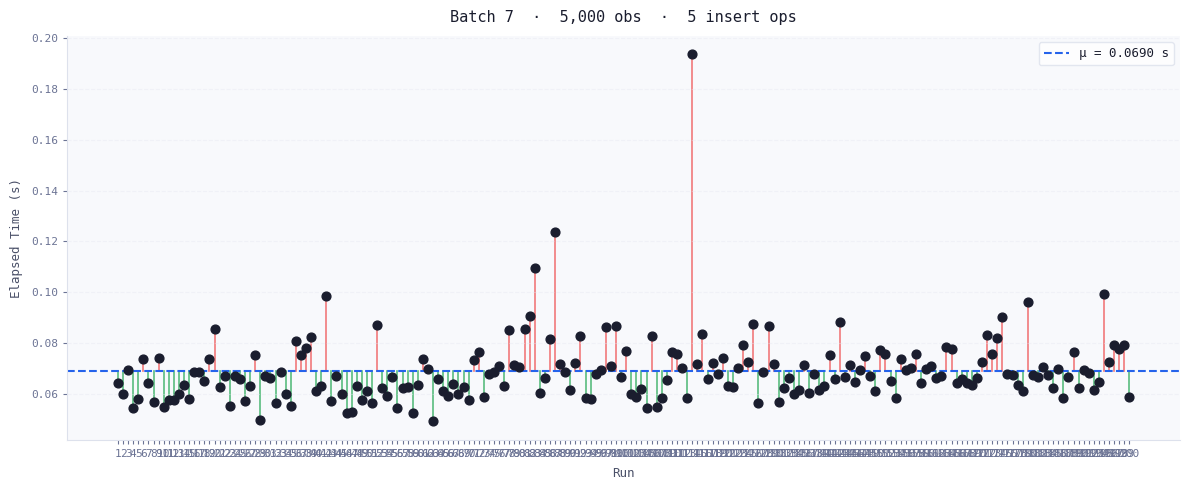

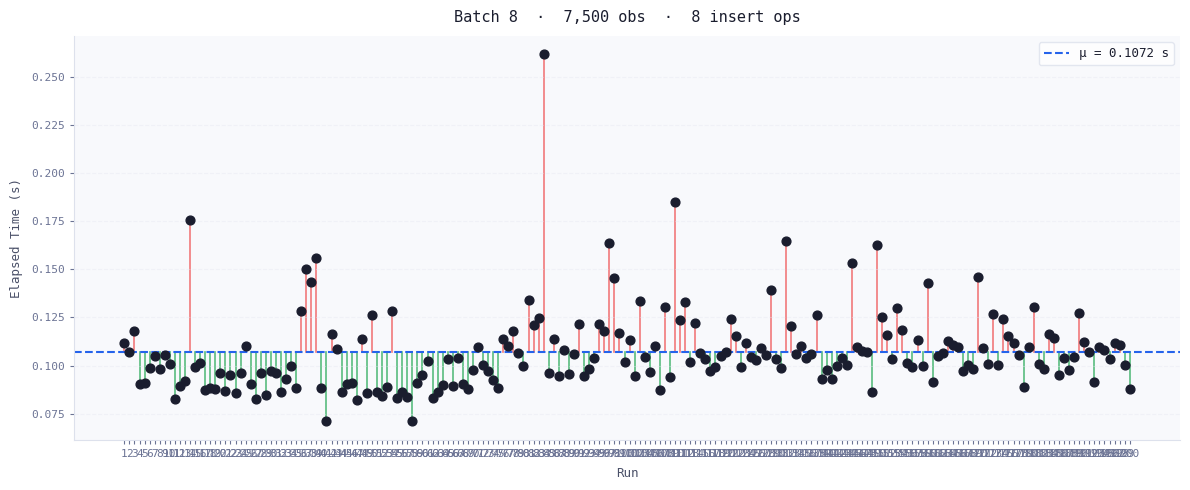

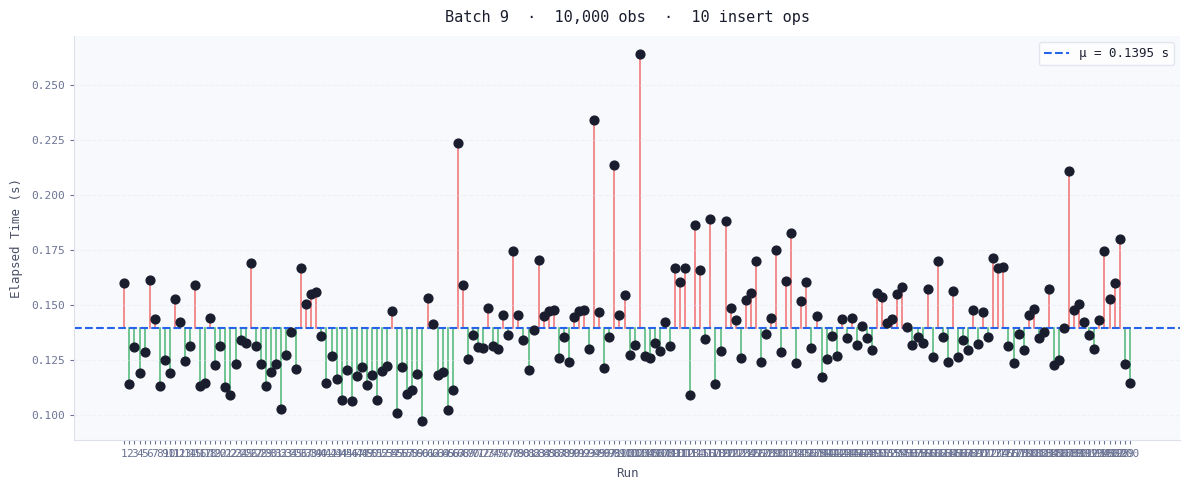

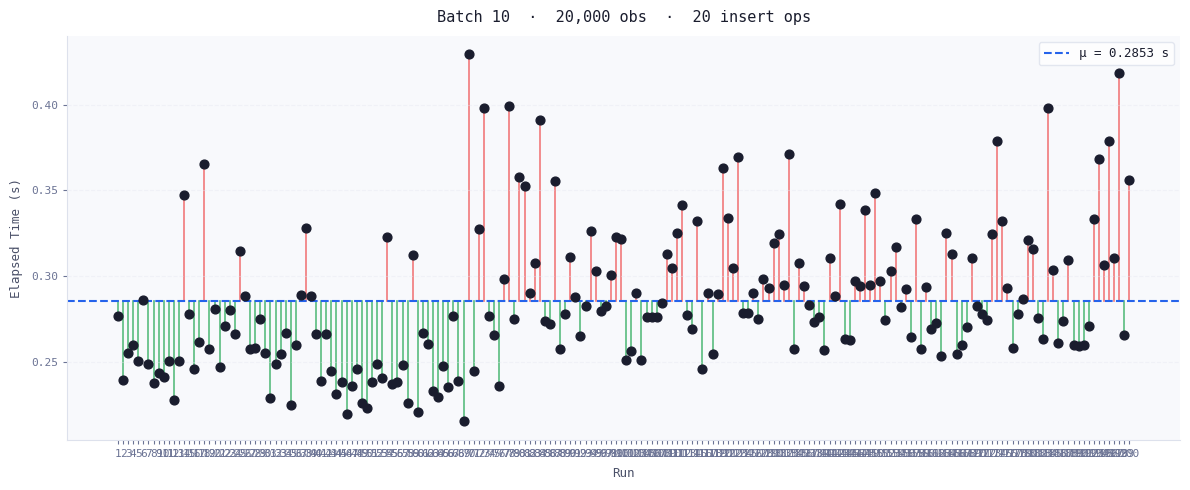

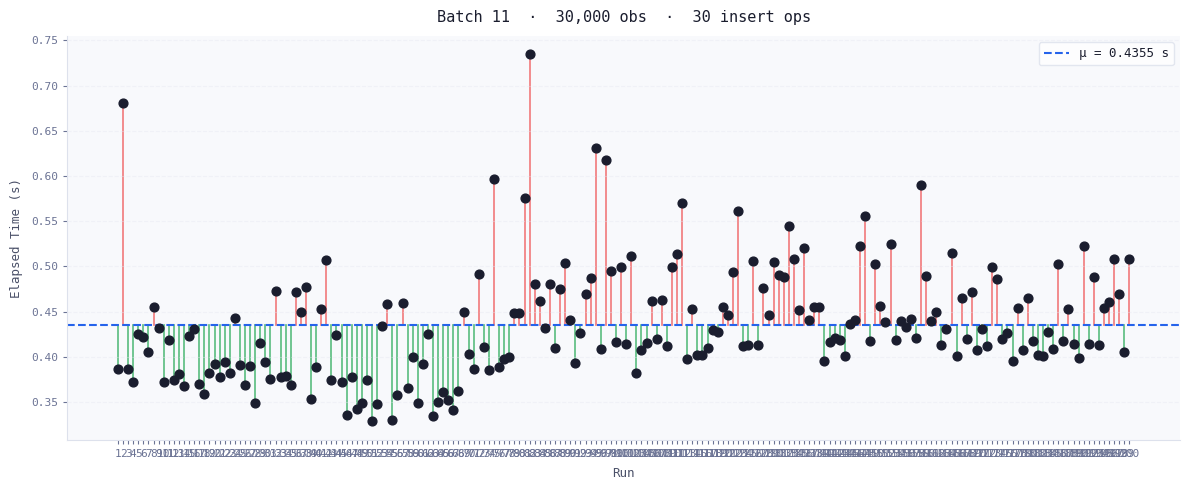

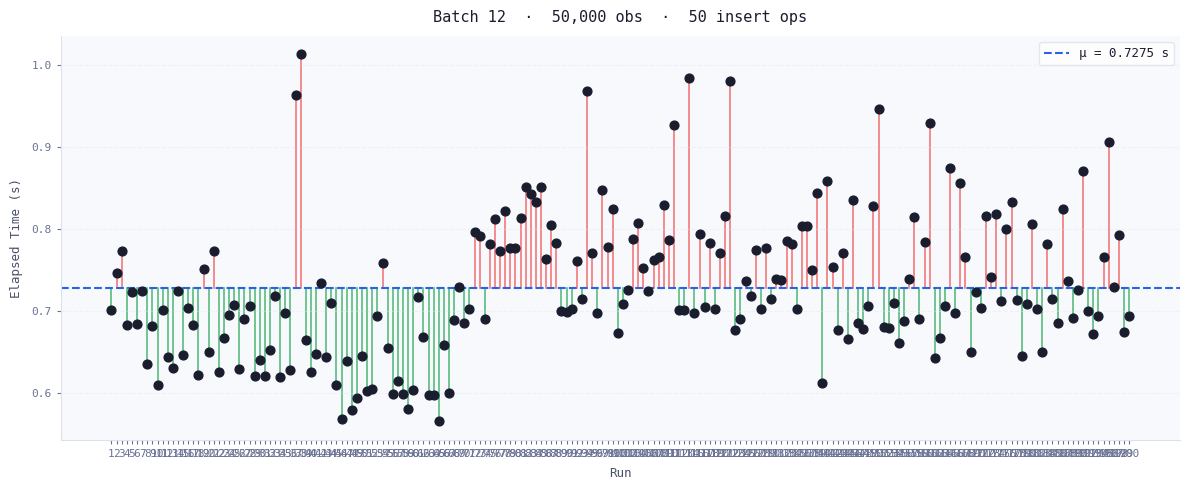

In [108]:
import matplotlib.pyplot as plt
import numpy as np

for batch_id in range(1, 13):
    batch_results = sorted(
        [r for r in benchmark_ALL if r.batch_id == batch_id],
        key=lambda r: r.created_at
    )
    elapsed_times = [r.elapsed_time_seconds for r in batch_results]
    run_numbers = list(range(1, len(elapsed_times) + 1))

    if len(elapsed_times) < 2:
        continue

    mu = np.mean(elapsed_times)
    insert_ops = batch_results[0].insert_operation_count

    fig, ax = plt.subplots(figsize=(12, 5))
    fig.patch.set_facecolor('#ffffff')
    ax.set_facecolor('#f8f9fc')

    ax.axhline(mu, color='#2563eb', linewidth=1.5, linestyle='--', label=f'μ = {mu:.4f} s', zorder=2)

    for run, t in zip(run_numbers, elapsed_times):
        color = '#ef4444' if t > mu else '#16a34a'
        ax.plot([run, run], [mu, t], color=color, linewidth=1.2, alpha=0.7, zorder=1)

    ax.scatter(run_numbers, elapsed_times, color='#1a1d2e', s=40, zorder=3)

    ax.set_title(
        f"Batch {batch_id}  ·  {batch_results[0].record_count:,} obs  ·  {insert_ops} insert ops",
        fontsize=11, pad=10, color='#1a1d2e'
    )
    ax.set_xlabel("Run", fontsize=9, labelpad=6)
    ax.set_ylabel("Elapsed Time (s)", fontsize=9, labelpad=6)
    ax.set_xticks(run_numbers)
    ax.tick_params(axis='both', length=3, labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#dde1ec')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, axis='y', alpha=0.4, color='#e4e7f0', linestyle='--')

    plt.tight_layout()
    plt.show()

## ms

In [109]:
# import matplotlib.pyplot as plt
# import numpy as np

# for batch_id in range(1, 13):
#     batch_results = sorted(
#         [r for r in benchmark_ALL if r.batch_id == batch_id],
#         key=lambda r: r.created_at
#     )
#     elapsed_times_ms = [r.elapsed_time_seconds * 1000 for r in batch_results]
#     run_numbers = list(range(1, len(elapsed_times_ms) + 1))

#     if len(elapsed_times_ms) < 2:
#         continue

#     mu = np.mean(elapsed_times_ms)
#     insert_ops = batch_results[0].insert_operation_count

#     fig, ax = plt.subplots(figsize=(12, 5))
#     fig.patch.set_facecolor('#ffffff')
#     ax.set_facecolor('#f8f9fc')

#     ax.axhline(mu, color='#2563eb', linewidth=1.5, linestyle='--', label=f'μ = {mu:.2f} ms', zorder=2)

#     for run, t in zip(run_numbers, elapsed_times_ms):
#         color = '#ef4444' if t > mu else '#16a34a'
#         ax.plot([run, run], [mu, t], color=color, linewidth=1.2, alpha=0.7, zorder=1)

#     ax.scatter(run_numbers, elapsed_times_ms, color='#1a1d2e', s=40, zorder=3)

#     ax.set_title(
#         f"Batch {batch_id}  ·  {batch_results[0].record_count:,} obs  ·  {insert_ops} insert ops",
#         fontsize=11, pad=10, color='#1a1d2e'
#     )
#     ax.set_xlabel("Run", fontsize=9, labelpad=6)
#     ax.set_ylabel("Elapsed Time (ms)", fontsize=9, labelpad=6)
#     ax.set_xticks(run_numbers)
#     ax.tick_params(axis='both', length=3, labelsize=8)
#     ax.spines[['top', 'right']].set_visible(False)
#     ax.spines[['left', 'bottom']].set_color('#dde1ec')
#     ax.legend(fontsize=9, loc='upper right')
#     ax.grid(True, axis='y', alpha=0.4, color='#e4e7f0', linestyle='--')

#     plt.tight_layout()
#     plt.show()

## normal

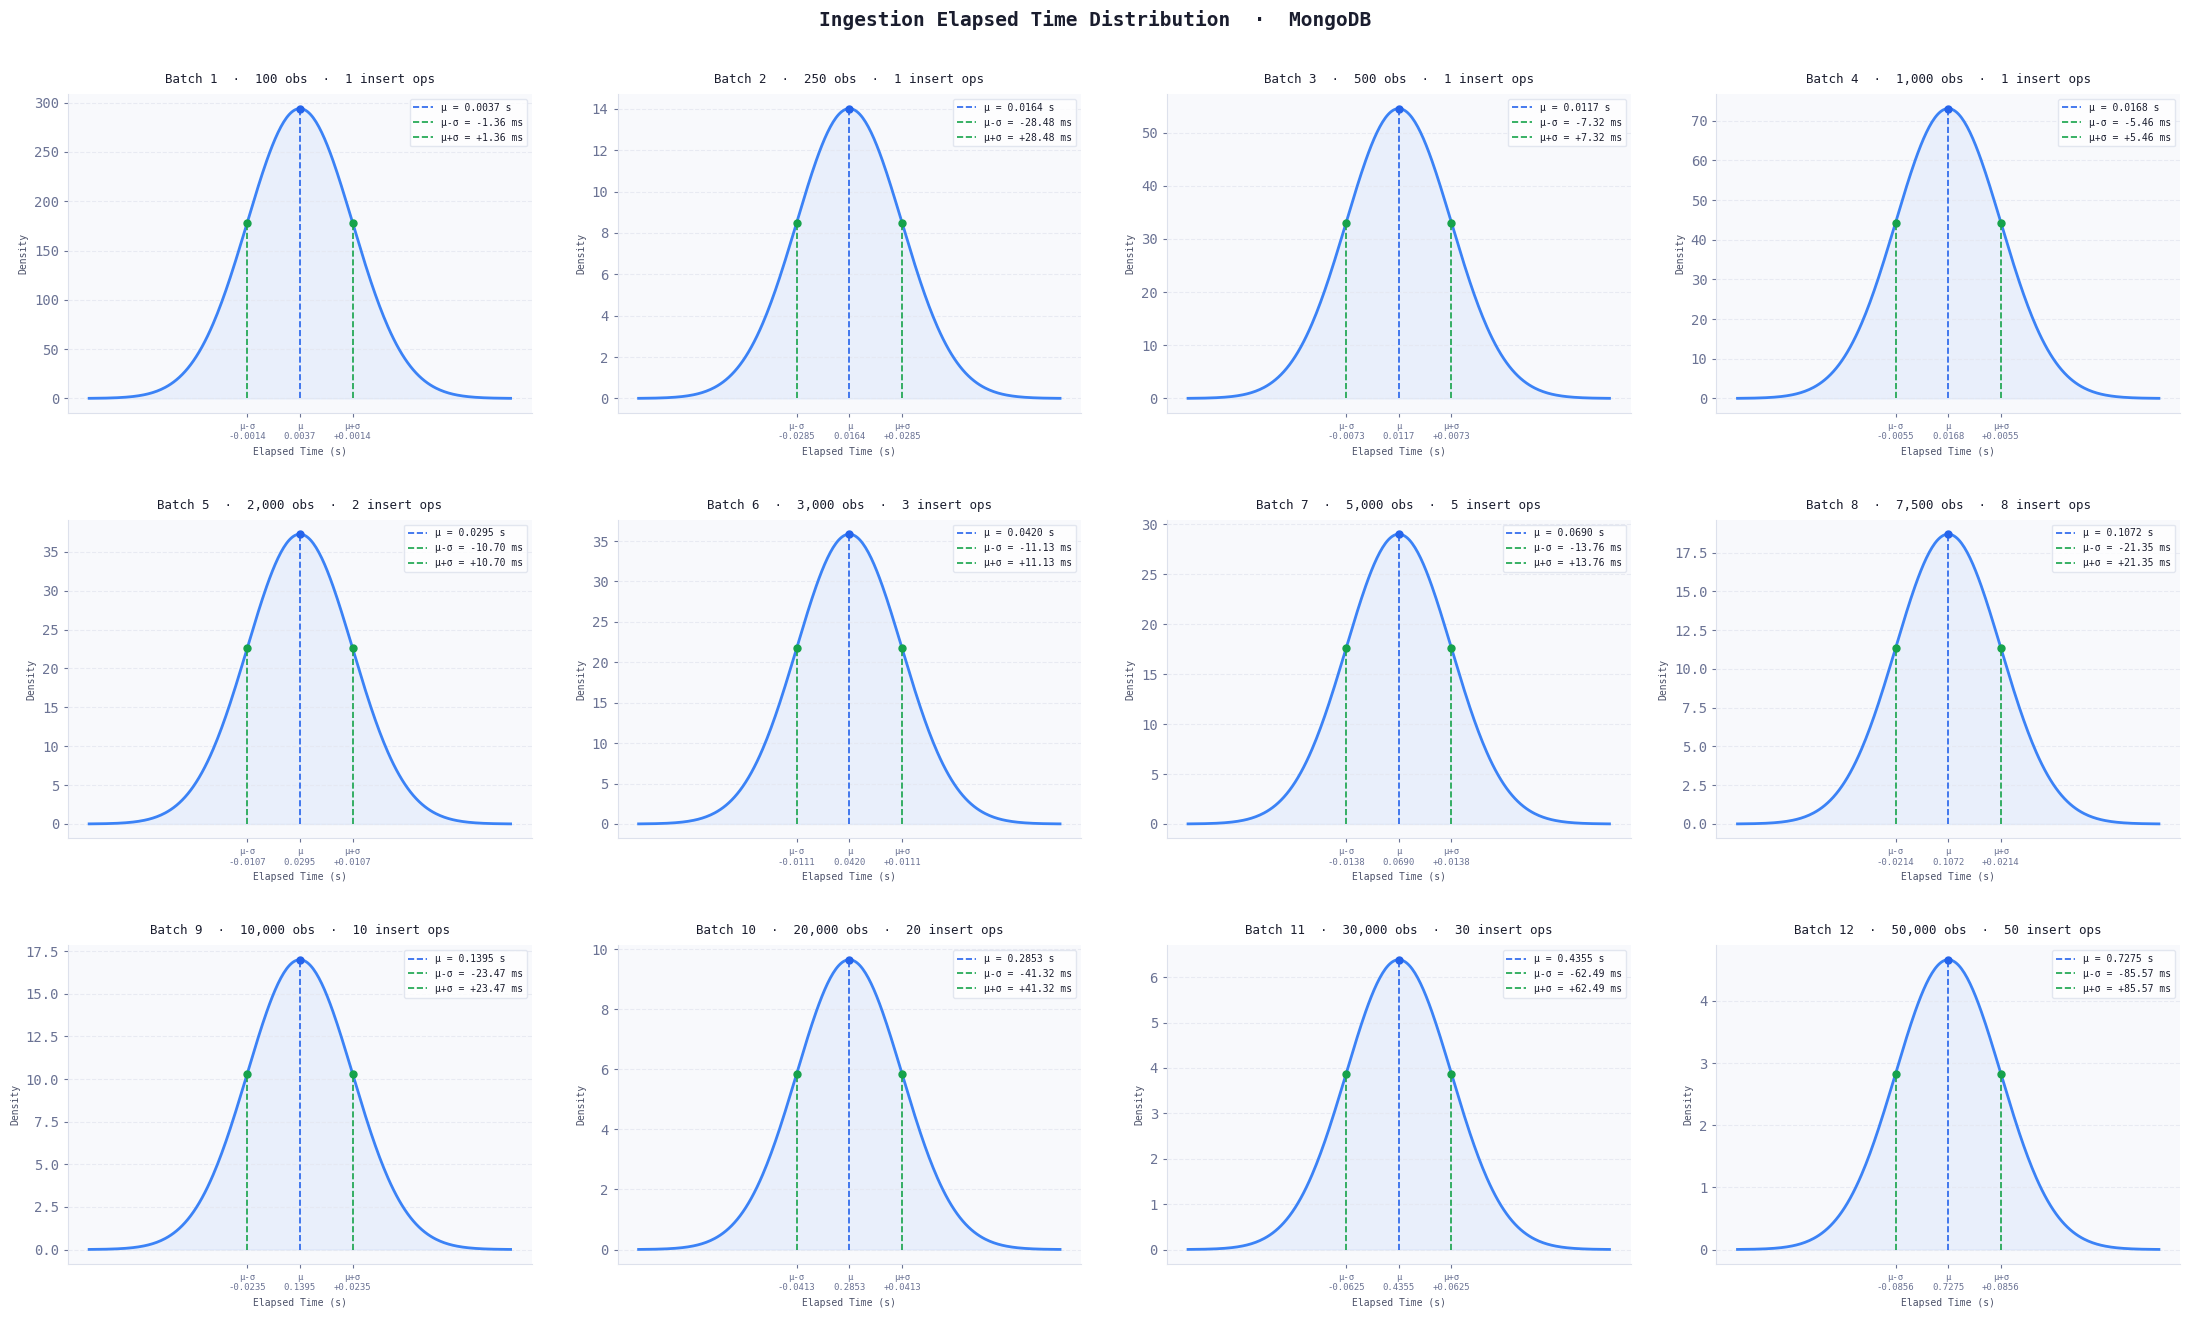

In [110]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

plt.rcParams.update({
    'figure.facecolor': '#ffffff',
    'axes.facecolor': '#f8f9fc',
    'axes.edgecolor': '#dde1ec',
    'axes.labelcolor': '#4a5068',
    'axes.titlecolor': '#1a1d2e',
    'xtick.color': '#6b7394',
    'ytick.color': '#6b7394',
    'grid.color': '#e4e7f0',
    'grid.linestyle': '--',
    'grid.alpha': 0.8,
    'text.color': '#1a1d2e',
    'font.family': 'monospace',
    'legend.facecolor': '#ffffff',
    'legend.edgecolor': '#dde1ec',
})

fig, axes = plt.subplots(3, 4, figsize=(22, 13))
fig.patch.set_facecolor('#ffffff')
axes = axes.flatten()

for i, batch_id in enumerate(range(1, 13)):
    batch_results = sorted(
        [r for r in benchmark_ALL if r.batch_id == batch_id],
        key=lambda r: r.created_at
    )
    elapsed_times = [r.elapsed_time_seconds for r in batch_results]

    if len(elapsed_times) < 2:
        axes[i].set_title(f"Batch {batch_id} - not enough data")
        continue

    mu, std = norm.fit(elapsed_times)
    std_ms = std * 1000
    insert_ops = batch_results[0].insert_operation_count

    x = np.linspace(mu - 4*std, mu + 4*std, 300)
    p = norm.pdf(x, mu, std)

    def p_at(val):
        return norm.pdf(val, mu, std)

    axes[i].fill_between(x, p, alpha=0.08, color='#3b82f6')
    axes[i].plot(x, p, color='#3b82f6', linewidth=2)

    for val, color, label in [
        (mu,       '#2563eb', f'μ = {mu:.4f} s'),
        (mu - std, '#16a34a', f'μ-σ = -{std_ms:.2f} ms'),
        (mu + std, '#16a34a', f'μ+σ = +{std_ms:.2f} ms'),
    ]:
        y_val = p_at(val)
        axes[i].plot([val, val], [0, y_val], color=color, linestyle='--', linewidth=1.2, label=label)
        axes[i].plot(val, y_val, 'o', color=color, markersize=5, zorder=5)

    axes[i].set_title(
        f"Batch {batch_id}  ·  {batch_results[0].record_count:,} obs  ·  {insert_ops} insert ops",
        fontsize=9, pad=8
    )
    axes[i].set_xlabel("Elapsed Time (s)", fontsize=7, labelpad=4)
    axes[i].set_ylabel("Density", fontsize=7, labelpad=4)

    axes[i].set_xticks([mu - std, mu, mu + std])
    axes[i].set_xticklabels([
        f'μ-σ\n-{std:.4f}',
        f'μ\n{mu:.4f}',
        f'μ+σ\n+{std:.4f}',
    ], fontsize=6.5)

    axes[i].tick_params(axis='both', length=3)
    axes[i].spines[['top', 'right']].set_visible(False)
    axes[i].spines[['left', 'bottom']].set_color('#dde1ec')
    axes[i].legend(fontsize=7, loc='upper right')
    axes[i].grid(True, axis='y')

fig.suptitle("Ingestion Elapsed Time Distribution  ·  MongoDB",
             fontsize=14, fontweight='bold', color='#1a1d2e', y=1.01)

plt.tight_layout(h_pad=3, w_pad=2)
plt.show()

##  how much the std is as a percentage of the mean

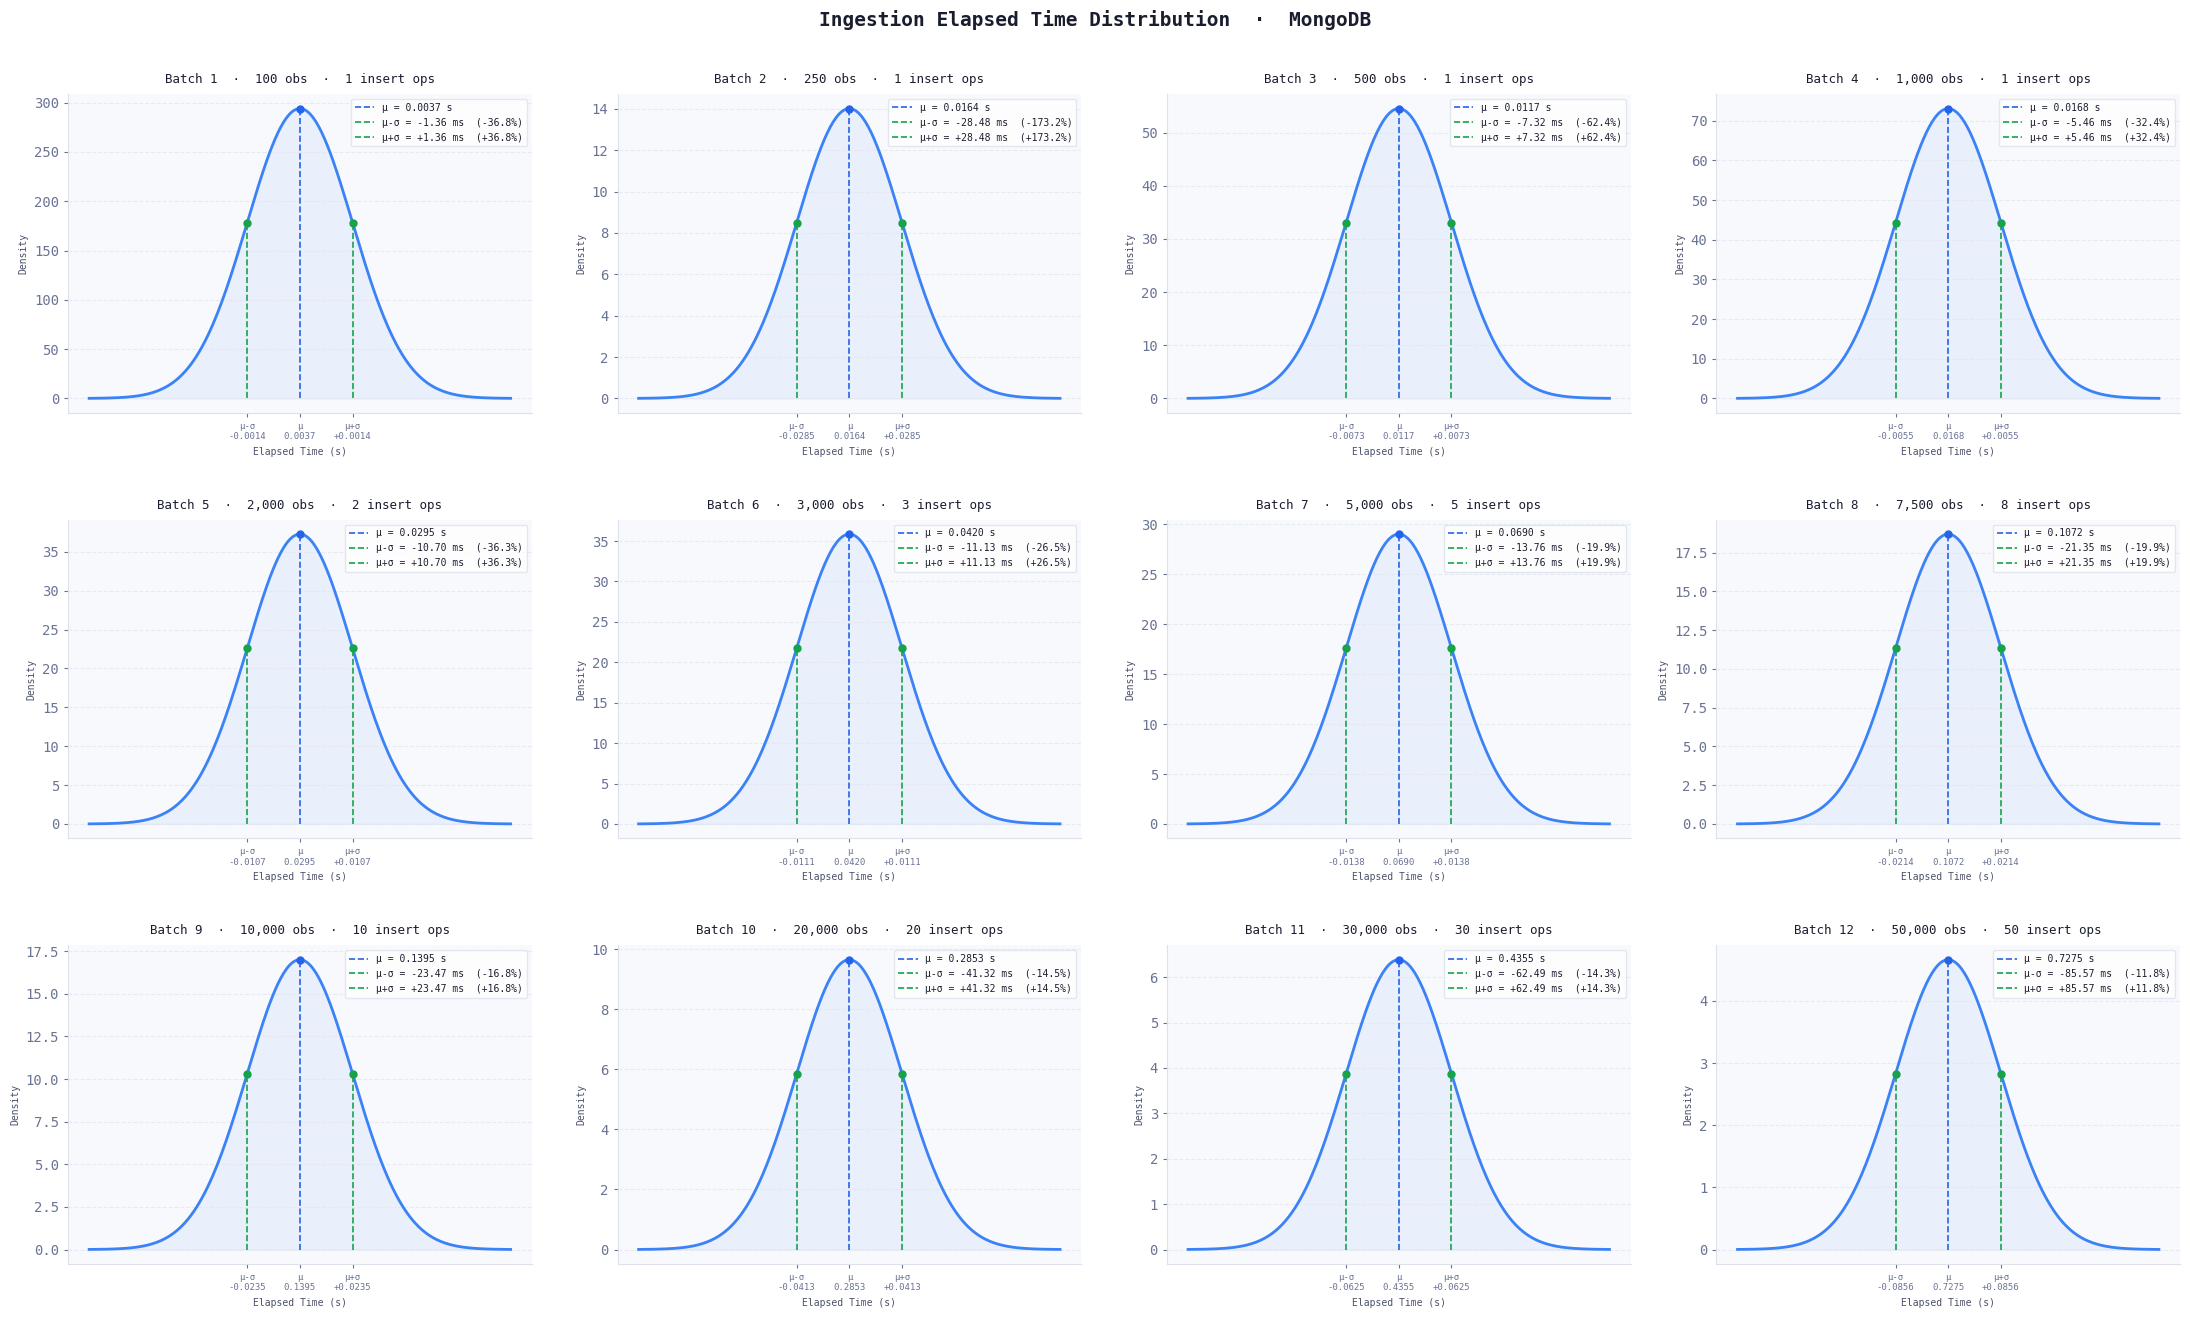

In [111]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

plt.rcParams.update({
    'figure.facecolor': '#ffffff',
    'axes.facecolor': '#f8f9fc',
    'axes.edgecolor': '#dde1ec',
    'axes.labelcolor': '#4a5068',
    'axes.titlecolor': '#1a1d2e',
    'xtick.color': '#6b7394',
    'ytick.color': '#6b7394',
    'grid.color': '#e4e7f0',
    'grid.linestyle': '--',
    'grid.alpha': 0.8,
    'text.color': '#1a1d2e',
    'font.family': 'monospace',
    'legend.facecolor': '#ffffff',
    'legend.edgecolor': '#dde1ec',
})

fig, axes = plt.subplots(3, 4, figsize=(22, 13))
fig.patch.set_facecolor('#ffffff')
axes = axes.flatten()

for i, batch_id in enumerate(range(1, 13)):
    batch_results = sorted(
        [r for r in benchmark_ALL if r.batch_id == batch_id],
        key=lambda r: r.created_at
    )
    elapsed_times = [r.elapsed_time_seconds for r in batch_results]

    if len(elapsed_times) < 2:
        axes[i].set_title(f"Batch {batch_id} - not enough data")
        continue

    mu, std = norm.fit(elapsed_times)
    std_ms = std * 1000
    std_pct = (std / mu) * 100
    insert_ops = batch_results[0].insert_operation_count

    x = np.linspace(mu - 4*std, mu + 4*std, 300)
    p = norm.pdf(x, mu, std)

    def p_at(val):
        return norm.pdf(val, mu, std)

    axes[i].fill_between(x, p, alpha=0.08, color='#3b82f6')
    axes[i].plot(x, p, color='#3b82f6', linewidth=2)

    for val, color, label in [
        (mu,       '#2563eb', f'μ = {mu:.4f} s'),
        (mu - std, '#16a34a', f'μ-σ = -{std_ms:.2f} ms  (-{std_pct:.1f}%)'),
        (mu + std, '#16a34a', f'μ+σ = +{std_ms:.2f} ms  (+{std_pct:.1f}%)'),
    ]:
        y_val = p_at(val)
        axes[i].plot([val, val], [0, y_val], color=color, linestyle='--', linewidth=1.2, label=label)
        axes[i].plot(val, y_val, 'o', color=color, markersize=5, zorder=5)

    axes[i].set_title(
        f"Batch {batch_id}  ·  {batch_results[0].record_count:,} obs  ·  {insert_ops} insert ops",
        fontsize=9, pad=8
    )
    axes[i].set_xlabel("Elapsed Time (s)", fontsize=7, labelpad=4)
    axes[i].set_ylabel("Density", fontsize=7, labelpad=4)

    axes[i].set_xticks([mu - std, mu, mu + std])
    axes[i].set_xticklabels([
        f'μ-σ\n-{std:.4f}',
        f'μ\n{mu:.4f}',
        f'μ+σ\n+{std:.4f}',
    ], fontsize=6.5)

    axes[i].tick_params(axis='both', length=3)
    axes[i].spines[['top', 'right']].set_visible(False)
    axes[i].spines[['left', 'bottom']].set_color('#dde1ec')
    axes[i].legend(fontsize=7, loc='upper right')
    axes[i].grid(True, axis='y')

fig.suptitle("Ingestion Elapsed Time Distribution  ·  MongoDB",
             fontsize=14, fontweight='bold', color='#1a1d2e', y=1.01)

plt.tight_layout(h_pad=3, w_pad=2)
plt.show()

## many dbs Throghput

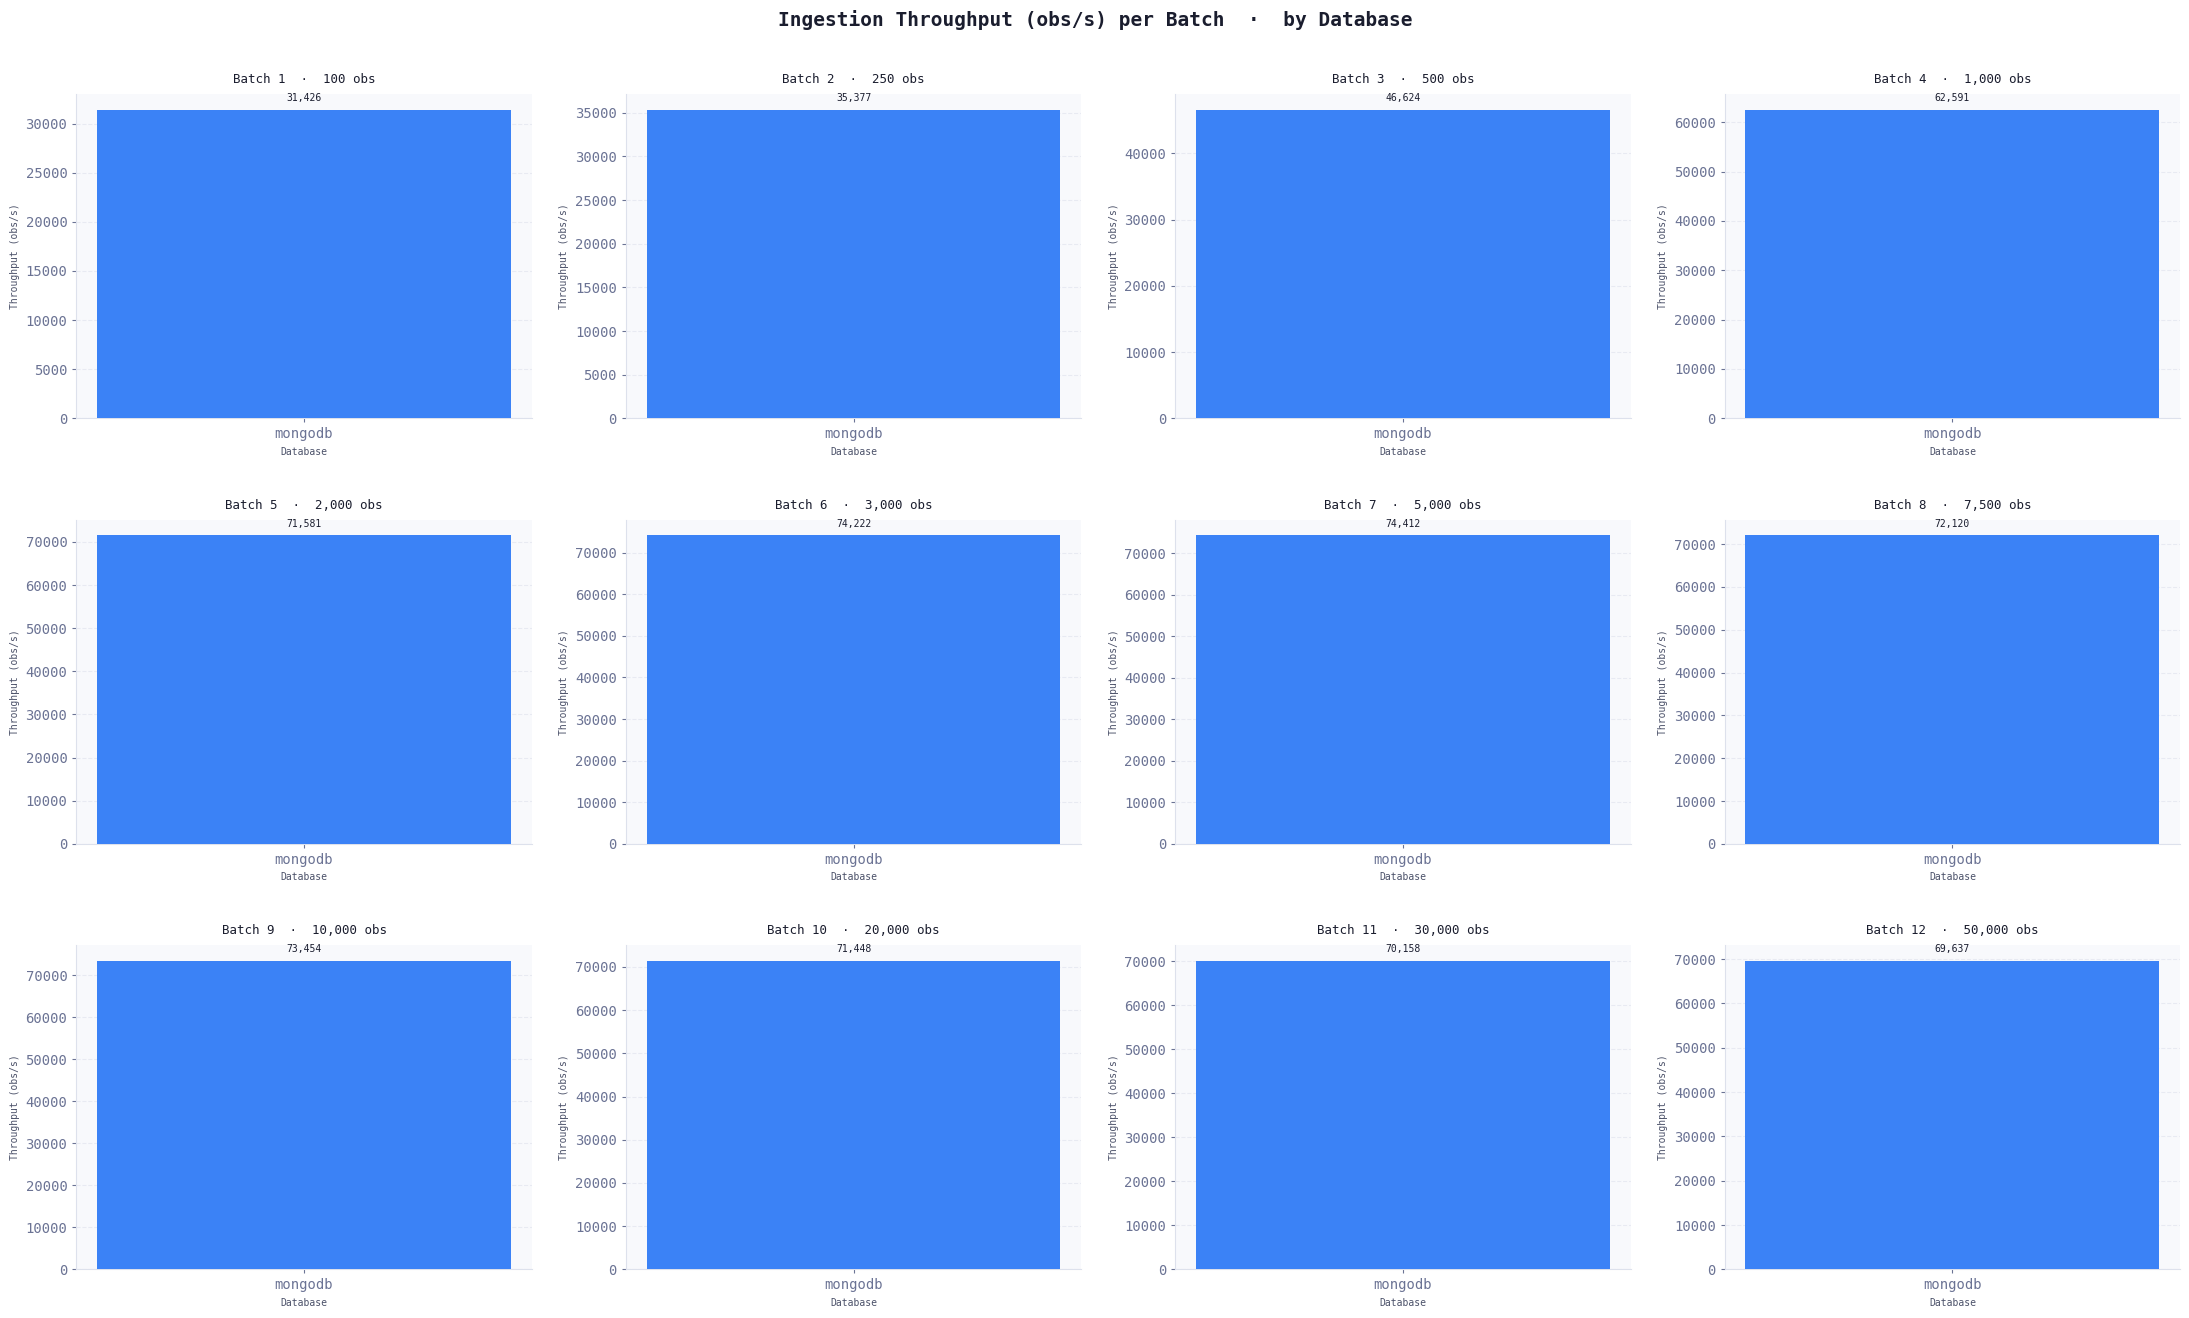

In [112]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'figure.facecolor': '#ffffff',
    'axes.facecolor': '#f8f9fc',
    'axes.edgecolor': '#dde1ec',
    'axes.labelcolor': '#4a5068',
    'axes.titlecolor': '#1a1d2e',
    'xtick.color': '#6b7394',
    'ytick.color': '#6b7394',
    'grid.color': '#e4e7f0',
    'grid.linestyle': '--',
    'grid.alpha': 0.8,
    'text.color': '#1a1d2e',
    'font.family': 'monospace',
    'legend.facecolor': '#ffffff',
    'legend.edgecolor': '#dde1ec',
})

fig, axes = plt.subplots(3, 4, figsize=(22, 13))
fig.patch.set_facecolor('#ffffff')
axes = axes.flatten()

for i, batch_id in enumerate(range(1, 13)):
    batch_results = [r for r in benchmark_ALL if r.batch_id == batch_id]

    if not batch_results:
        axes[i].set_title(f"Batch {batch_id} - no data")
        continue

    db_systems = list({r.database_system for r in batch_results})
    throughputs = [
        np.mean([r.throughput_obs_per_sec for r in batch_results if r.database_system == db])
        for db in db_systems
    ]

    colors = ['#3b82f6', '#f59e0b', '#10b981', '#ef4444']
    bars = axes[i].bar(db_systems, throughputs, color=colors[:len(db_systems)], width=0.4, zorder=3)

    for bar, val in zip(bars, throughputs):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(throughputs) * 0.02,
            f'{val:,.0f}',
            ha='center', va='bottom', fontsize=7, color='#1a1d2e'
        )

    axes[i].set_title(
        f"Batch {batch_id}  ·  {batch_results[0].record_count:,} obs",
        fontsize=9, pad=8
    )
    axes[i].set_xlabel("Database", fontsize=7, labelpad=4)
    axes[i].set_ylabel("Throughput (obs/s)", fontsize=7, labelpad=4)
    axes[i].spines[['top', 'right']].set_visible(False)
    axes[i].spines[['left', 'bottom']].set_color('#dde1ec')
    axes[i].tick_params(axis='both', length=3)
    axes[i].grid(True, axis='y', zorder=0)

fig.suptitle("Ingestion Throughput (obs/s) per Batch  ·  by Database",
             fontsize=14, fontweight='bold', color='#1a1d2e', y=1.01)

plt.tight_layout(h_pad=3, w_pad=2)
plt.show()